In [1]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
import os
import operator
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage],add_messages]

In [3]:
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

def chat_node(state : ChatState) -> ChatState:

    # take user query
    messages = state["messages"]

    # send it to llm
    response = llm.invoke(messages)

    # response store in state
    return{'messages':[response]}

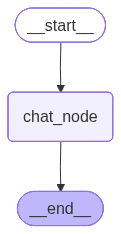

In [4]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add node
graph.add_node('chat_node',chat_node)

# add edge
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

# compile
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [8]:
thread_id = "1"
config = {"configurable": {"thread_id": thread_id}}

initial_state = {
    "messages": [HumanMessage(content="What is the capital of India")]
}
chatbot.invoke(initial_state, config=config)["messages"][-1].content

'The capital of India is New Delhi.'

In [9]:
thread_id = "1"
config = {"configurable": {"thread_id": thread_id}}

while True:
    user_message = input("Type here: ")
    print("User:", user_message)

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break

    response = chatbot.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config=config
    )
    print("AI:", response["messages"][-1].content)

User: hi my name is shrishtii
AI: Nice to meet you, Shrishtii! How are you today?
User: so what is my name?
AI: Your name is Shrishtii.
User: also what is 10 + 120
AI: To calculate that, I'll add 10 and 120 together:

10 + 120 = 130

So the answer is 130.
User: so add 10 more to the previous result
AI: We previously got 130. Adding 10 to that:

130 + 10 = 140

So the new result is 140.
User: okay good bye
AI: Goodbye Shrishtii. Have a great day!
User: bye


In [10]:
# memory issue
# cant remember the last conversation
# so use threads and config

In [11]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='47c0e07e-aca5-448a-90c2-b7d330f2aab7'), AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 41, 'total_tokens': 50, 'completion_time': 0.008833533, 'completion_tokens_details': None, 'prompt_time': 0.003088623, 'prompt_tokens_details': None, 'queue_time': 0.047243226, 'total_time': 0.011922156}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce683-fd2a-7d21-b958-40220fab9b8a-0', usage_metadata={'input_tokens': 41, 'output_tokens': 9, 'total_tokens': 50}), HumanMessage(content='hi my name is shrishtii', additional_kwargs={}, response_metadata={}, id='28258943-f25c-42ae-be38-64b99be41059'), AIMessage(content='Nice to meet you, Shrishtii! How